In [3]:
!pip uninstall -y keras tensorflow
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install transformers
!pip install transformers datasets torch
# !pip install --upgrade --force-reinstall pyarrow==16.1.0 --no-deps -q
!pip install -U transformers datasets accelerate

# import importlib, pyarrow
# importlib.reload(pyarrow)

from datasets import Dataset

Looking in indexes: https://download.pytorch.org/whl/cpu


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import torch

!pip install ipywidgets
# jupyter nbextension enable --py widgetsnbextension --sys-prefix
!pip install jupyterlab_widgets


In [7]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV

# Import dataset from final_data_version.csv
df_balanced = pd.read_csv("../data/final_data_version.csv")

# Split my data
(X_train, X_test, y_train, y_test) = train_test_split(df_balanced.description, df_balanced.category, test_size=0.2, random_state=42)

In [11]:
# Prepare data
le = LabelEncoder()
df_balanced['label'] = le.fit_transform(df_balanced['category'])

# Include title and author metadata
df_balanced['full_text'] = (
    df_balanced['title'] + ' by ' +
    df_balanced['authors'] + ': ' +
    df_balanced['description']
)

# Ensure correct column name
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['full_text'],
    df_balanced['label'],
    test_size=0.2,
    stratify=df_balanced['label'],
    random_state=42
)

# Convert to Hugging Face Datasets
train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
test_dataset  = Dataset.from_dict({'text': X_test.tolist(),  'label': y_test.tolist()})

In [24]:
# Experiment using the roBERTa - include metadata

# roberta Model
roberta_model_epochs = "roberta-base"

tokenizer_roberta_epochs = AutoTokenizer.from_pretrained(roberta_model_epochs)

def tokenize(batch):
    return tokenizer_roberta_epochs(batch['text'], padding='max_length', truncation=True, max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
# Load model
num_labels = len(le.classes_)
model = AutoModelForSequenceClassification.from_pretrained(roberta_model_epochs, num_labels=num_labels)

# Training config
training_args = TrainingArguments(
    output_dir="./results",
    do_eval=True,   
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,   
    metric_for_best_model="f1", 
    greater_is_better=True,
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1, 
    logging_dir="./logs",
    logging_steps=100,
    save_total_limit=2,
    report_to="none" 
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="weighted"),
        "recall": recall_score(labels, preds, average="weighted"),
        "f1": f1_score(labels, preds, average="weighted"),
    }


# Trainer
trainer_roberta_epochs = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer_roberta_epochs,
    compute_metrics=compute_metrics 
)

# Train
trainer_roberta_epochs.train()

Map:   0%|          | 0/38592 [00:00<?, ? examples/s]

Map:   0%|          | 0/9648 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/gs/rm1mjp5x5ybc93h8m4xwbfyr0000gn/T/ipykernel_23156/3650054521.py:53: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_roberta_epochs = Trainer(
/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.813700,0.815609,0.731654,0.738203,0.731654,0.731985
2,0.658800,0.786310,0.751866,0.753384,0.751866,0.752320


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=9648, training_loss=0.8346091583988955, metrics={'train_runtime': 5855.0867, 'train_samples_per_second': 13.182, 'train_steps_per_second': 1.648, 'total_flos': 1.0154711196499968e+16, 'train_loss': 0.8346091583988955, 'epoch': 2.0})

In [32]:
# Evaluate roBERTa Model
preds_output_roberta_epochs = trainer_roberta_epochs.predict(test_dataset)
y_pred_roberta_epochs = preds_output_roberta_epochs.predictions.argmax(axis=1)
print(classification_report(y_test, y_pred_roberta_epochs, target_names=le.classes_))

/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


                       precision    recall  f1-score   support

                  art       0.71      0.72      0.71      1000
     business/finance       0.86      0.82      0.84       923
       fantasy/horror       0.68      0.70      0.69      1000
                 food       0.87      0.81      0.84       891
              history       0.71      0.72      0.71      1000
religion/spirituality       0.75      0.79      0.77      1000
              romance       0.78      0.80      0.79      1000
              science       0.73      0.72      0.73      1000
      science fiction       0.73      0.70      0.72       966
             thriller       0.74      0.76      0.75       868

             accuracy                           0.75      9648
            macro avg       0.76      0.75      0.75      9648
         weighted avg       0.75      0.75      0.75      9648



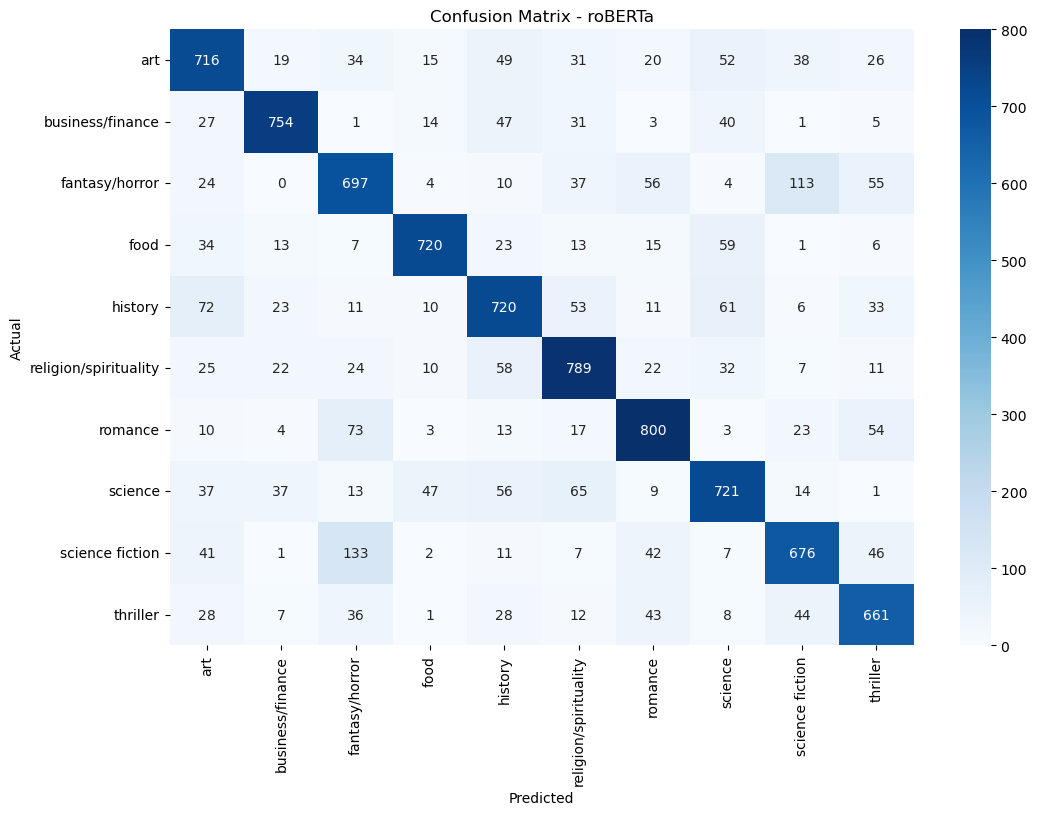

In [34]:
# Confusion matrix roBERTa

cm = confusion_matrix(y_test, y_pred_roberta_epochs, labels=range(len(le.classes_)))
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_,
            yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - roBERTa')
plt.show()

In [37]:
!pip install wordcloud

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Word Cloud for art


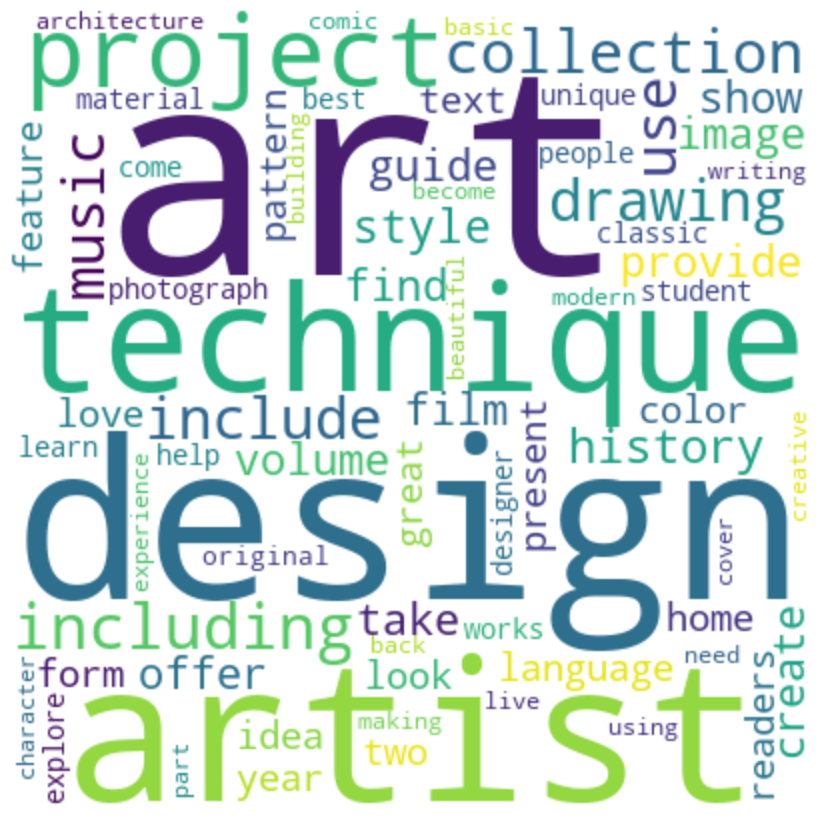

Word Cloud for business/finance


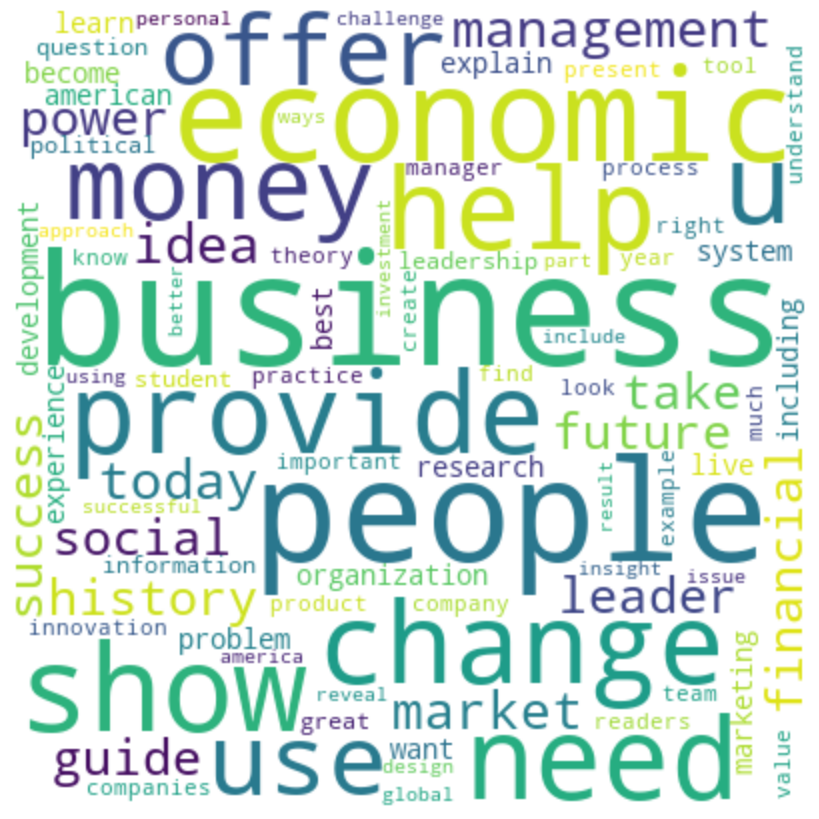

Word Cloud for fantasy/horror


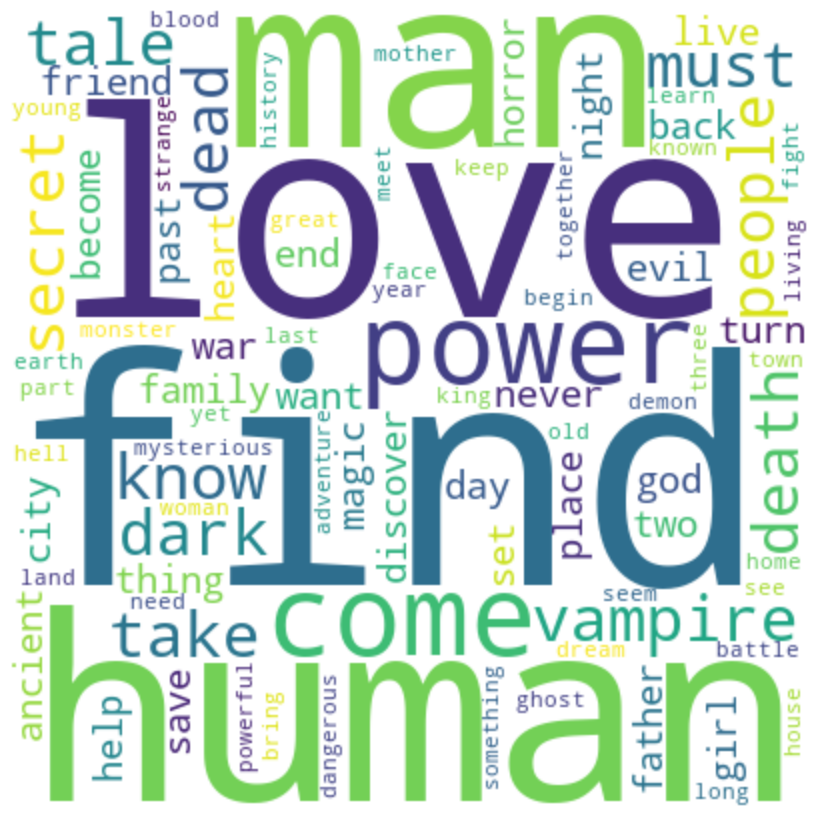

Word Cloud for food


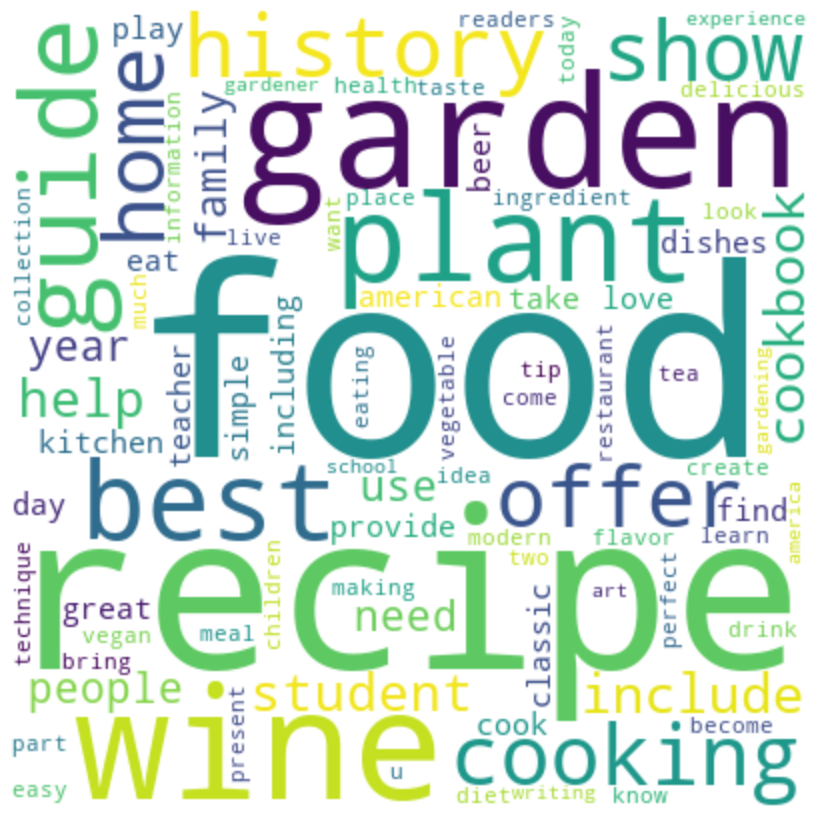

Word Cloud for history


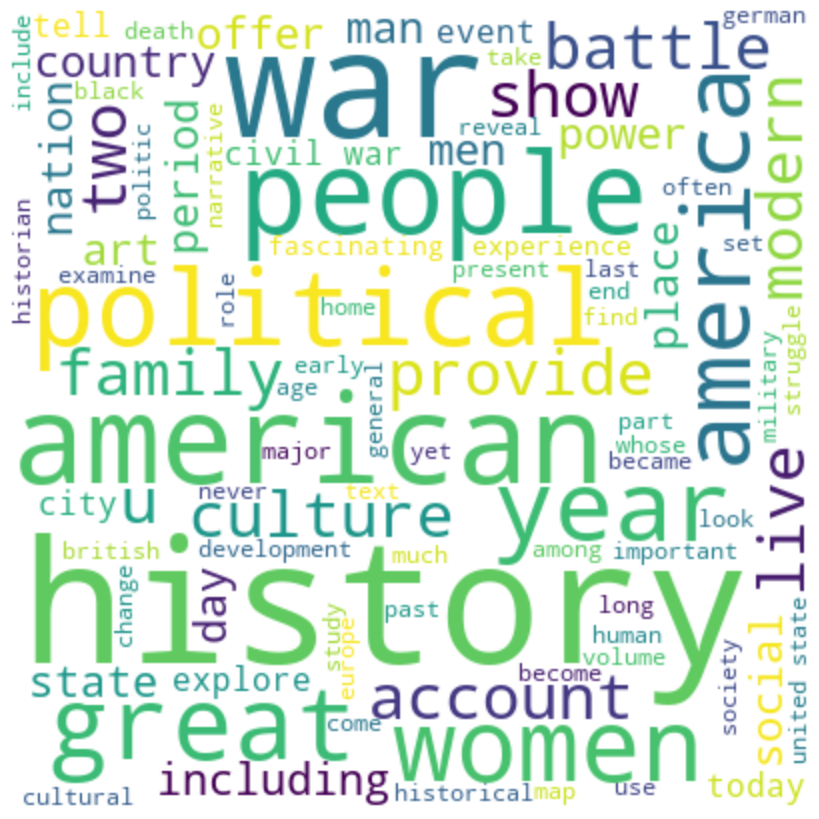

Word Cloud for religion/spirituality


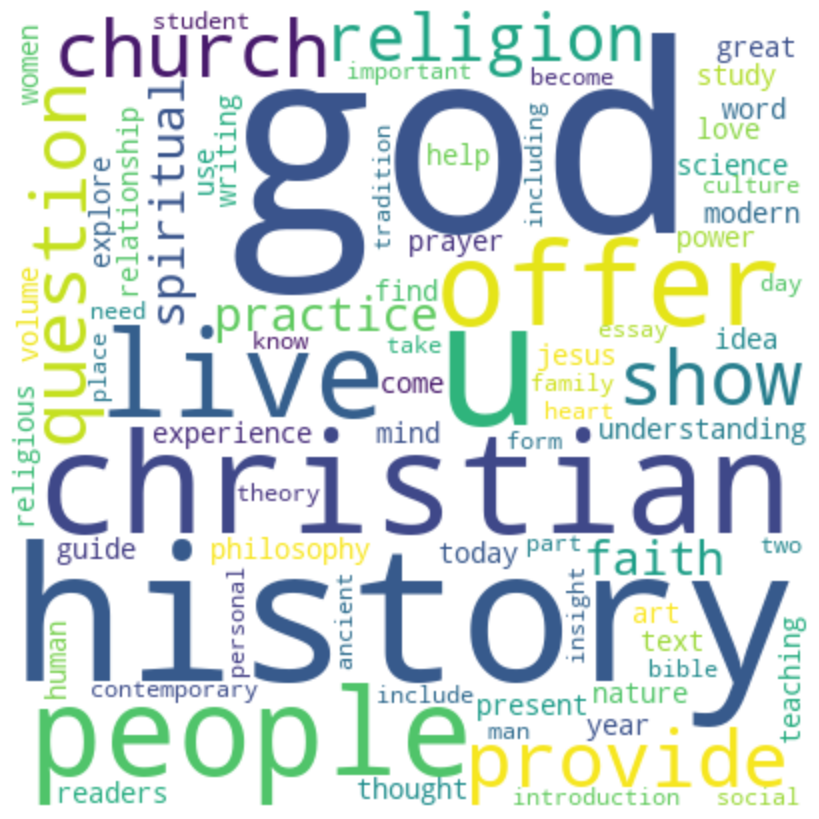

Word Cloud for romance


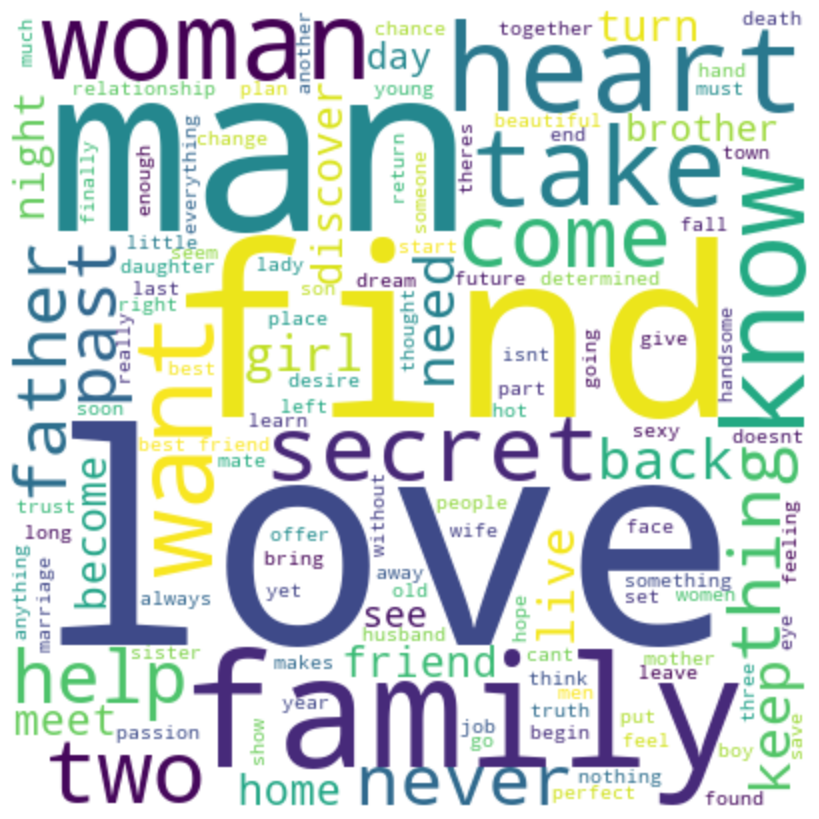

Word Cloud for science


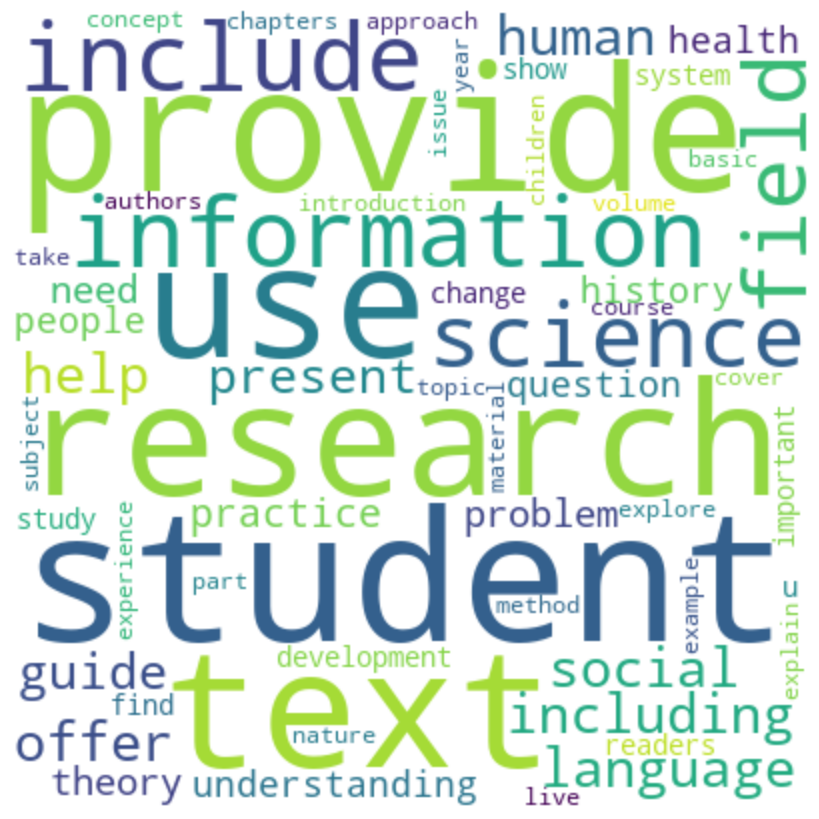

Word Cloud for science fiction


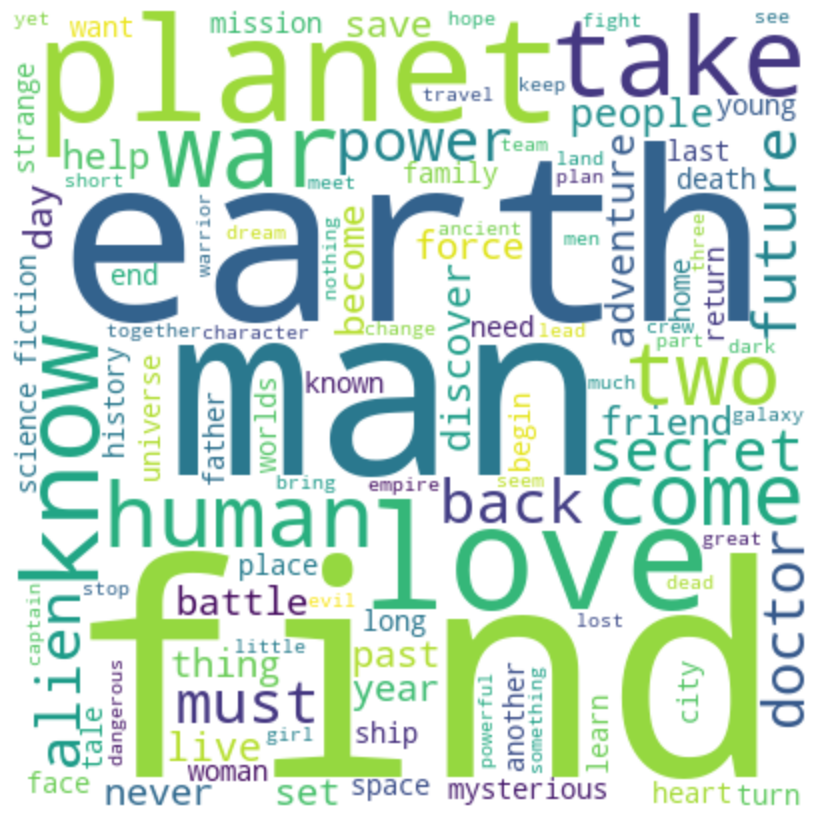

Word Cloud for thriller


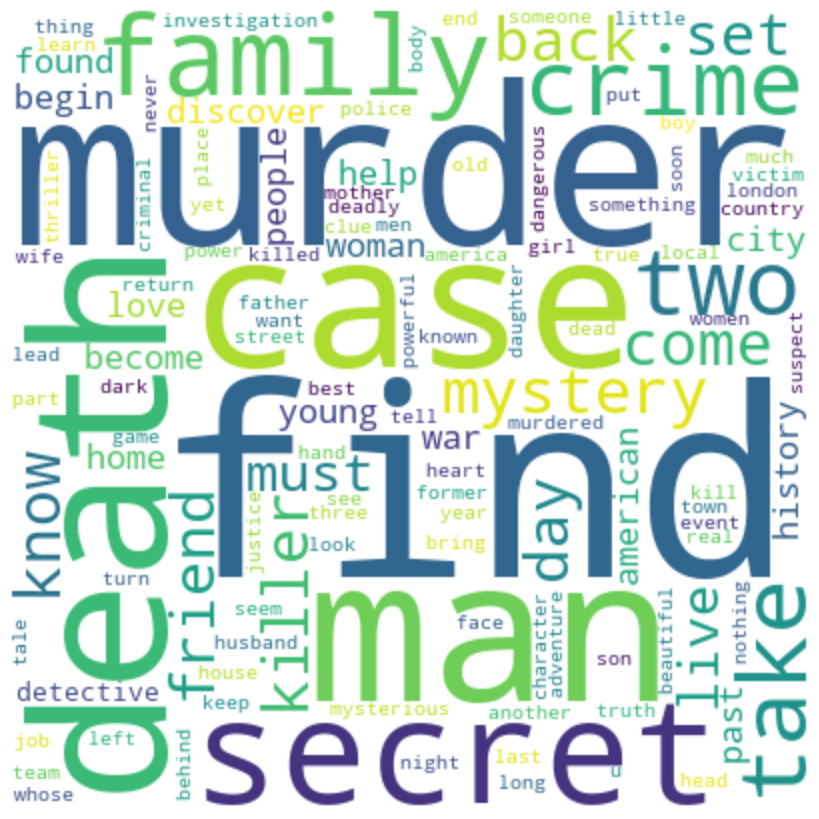

In [14]:
# Word Cloud

import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# Custom word stops that are common between categories to remove meaningless words
custom_words = {
    'book', 'books', 'story', 'stories', 'novel', 'author', 'writes', 'written',
    'one', 'also', 'many', 'would', 'could', 'may', 'might', 'like', 'well',
    'plot', 'said', 'told', 'made', 'make', 'every', 'around', 'across', 'within',
    'even', 'though', 'however', 'still', 'good', 'new', 'time', 'life', 'way',
    'chapter', 'read', 'reading', 'reader', 'series', 'pages', 'page', 'one', 'hes',
    'shes', 'she', 'he', 'will', 'work', 'now', 'will', 'first', 'world'
}

# Define stopwords
stopwords = set(STOPWORDS)
stopwords.update(custom_words)

# Function to generate a word cloud for a given category
def print_wordCloud(category, text):
    if not text.strip():
        print(f"No data for category: {category}")
        return
    print(f"Word Cloud for {category}")
    wordcloud = WordCloud(
        width=400,
        height=400,
        background_color='white',
        stopwords=stopwords,
        colormap='viridis',
        min_font_size=10
    ).generate(text)
    
    plt.figure(figsize=(8, 8), facecolor='white')
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.show()

# Function to combine all descriptions for a specific category
def make_string(category_name, data):
    text = ""
    for _, row in data.iterrows():
        if row['category'] == category_name:
            text += str(row['description']) + ' '
    return text

# Example usage
for category in le.classes_:
    combined_text = make_string(category, df_balanced)
    print_wordCloud(category, combined_text)


# Testing input against the model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import pandas as pd

model_path = "./results" 

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

import joblib
le = joblib.load("label_encoder.pkl") 


def predict_genre(description, title="", authors=""):
    full_text = f"{title} by {authors}: {description}".strip()

    inputs = tokenizer(
        full_text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=256
    )

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_label = torch.argmax(logits, dim=1).item()

    genre = le.inverse_transform([predicted_label])[0]
    return genre


test_title = "The Quantum Paradox"
test_author = "A. J. Fields"
test_description = """
A young physicist discovers a hidden dimension where time flows backwards, 
forcing her to choose between saving humanity or rewriting history.
"""

predicted_genre = predict_genre(test_description, test_title, test_author)
print("📚 Predicted Genre:", predicted_genre)

